In [3]:
import warnings
warnings.filterwarnings("ignore")

In [4]:
import scanpy as sc
import pandas as pd
import numpy as np
import torch
import dgl
import random
from scipy.sparse import csr_matrix
from sklearn.metrics import adjusted_rand_score as ari_score
from sklearn.metrics.cluster import normalized_mutual_info_score
import os

In [5]:
import so as so

In [6]:
seed = 42
random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
np.random.seed(seed)
dgl.random.seed(seed)

In [7]:
sc.set_figure_params(dpi=150, figsize=(2, 2), frameon=False)    # TODO 是否画边框

In [8]:
adata = sc.read_h5ad('./soDGVAE_dataset/dataset/4_3d_mouse_kidney/mouse_kidney3d_arrayseq.h5ad')
adata

AnnData object with n_obs × n_vars = 92769 × 15144
    obs: 'Tissue_ID', 'Subregion', 'subregion', 'region'
    var: 'gene_ids', 'feature_types', 'mt'
    uns: 'Subregion_colors', 'hvg', 'leiden', 'log1p', 'neighbors', 'pca', 'umap'
    obsm: 'X_pca', 'X_umap', 'spatial', 'spatial_2d', 'spatial_3d'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'

In [9]:
adata.obs

,Tissue_ID,Subregion,subregion,region
AAACCCAGCTCG-0-0-0-0-0-0-0,9,Cortex-PCT,Cortex-PCT,Cortex
AAACCCGACGAG-0-0-0-0-0-0-0,9,Cortex-PCT,Cortex-PCT,Cortex
AAACCCGAGGTG-0-0-0-0-0-0-0,9,Cortex-PCT,Cortex-PCT,Cortex
AAACCGAATCTC-0-0-0-0-0-0-0,9,Cortex-PCT,Cortex-PCT,Cortex
AAACCGCACTTA-0-0-0-0-0-0-0,9,Fat,Fat,Fat
...,...,...,...,...
TTTGGGCATCTC-1,2,Cortex-PCT,Cortex-PCT,Cortex
TTTGGTAGACGC-1,2,Medulla,Medulla,Medulla
TTTGGTCAGCAG-1,2,Medulla,Medulla,Medulla
TTTGGTCAGGAC-1,2,Cortex-PCT,Cortex-PCT,Cortex


In [10]:
adata.X.max()

4.628287

In [11]:
batches = ['2', '4', '5', '6', '7', '8', '9', '10']

In [12]:
data_list = [adata[adata.obs.loc[:, 'Tissue_ID'] == batch, :] for batch in batches]
data_list

[View of AnnData object with n_obs × n_vars = 10209 × 15144
     obs: 'Tissue_ID', 'Subregion', 'subregion', 'region'
     var: 'gene_ids', 'feature_types', 'mt'
     uns: 'Subregion_colors', 'hvg', 'leiden', 'log1p', 'neighbors', 'pca', 'umap'
     obsm: 'X_pca', 'X_umap', 'spatial', 'spatial_2d', 'spatial_3d'
     varm: 'PCs'
     obsp: 'connectivities', 'distances',
 View of AnnData object with n_obs × n_vars = 11273 × 15144
     obs: 'Tissue_ID', 'Subregion', 'subregion', 'region'
     var: 'gene_ids', 'feature_types', 'mt'
     uns: 'Subregion_colors', 'hvg', 'leiden', 'log1p', 'neighbors', 'pca', 'umap'
     obsm: 'X_pca', 'X_umap', 'spatial', 'spatial_2d', 'spatial_3d'
     varm: 'PCs'
     obsp: 'connectivities', 'distances',
 View of AnnData object with n_obs × n_vars = 11225 × 15144
     obs: 'Tissue_ID', 'Subregion', 'subregion', 'region'
     var: 'gene_ids', 'feature_types', 'mt'
     uns: 'Subregion_colors', 'hvg', 'leiden', 'log1p', 'neighbors', 'pca', 'umap'
     obsm: 

In [13]:
batch_key = 'batch'
adata = so.pp.process_adata(data_list, label=batch_key, keys=batches, n_top_features=3000, target_sum=1e4, scale=False, norm=False)
adata

AnnData object with n_obs × n_vars = 92769 × 3000
    obs: 'Tissue_ID', 'Subregion', 'subregion', 'region', 'original_index', 'spot_quality', 'batch'
    var: 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches'
    uns: 'mu_bg', 'std_bg'
    obsm: 'X_pca', 'X_umap', 'spatial', 'spatial_2d', 'spatial_3d'
    layers: 'counts'

In [29]:
rad_cutoff_list = [0.05] * len(data_list)
adata, g = so.pp.process_graph(adata, data_list, cutoff_list=rad_cutoff_list)

cal spatial net in data_list
------Calculating spatial graph...
The graph contains 59442 edges, 10209 cells.
5.8225 neighbors per cell on average.
------Calculating spatial graph...
The graph contains 65082 edges, 11273 cells.
5.7733 neighbors per cell on average.
------Calculating spatial graph...
The graph contains 65168 edges, 11225 cells.
5.8056 neighbors per cell on average.
------Calculating spatial graph...
The graph contains 67364 edges, 11685 cells.
5.7650 neighbors per cell on average.
------Calculating spatial graph...
The graph contains 73652 edges, 12712 cells.
5.7939 neighbors per cell on average.
------Calculating spatial graph...
The graph contains 71524 edges, 12291 cells.
5.8192 neighbors per cell on average.
------Calculating spatial graph...
The graph contains 70504 edges, 12127 cells.
5.8138 neighbors per cell on average.
------Calculating spatial graph...
The graph contains 65708 edges, 11247 cells.
5.8423 neighbors per cell on average.


In [30]:
path_results = f'./log/result/'

In [31]:
adata_STAX = so.model.DGVAE(adata=adata,
                            n_epoch=5,
                            batch_size=1024,
                            verbose=False,
                            gpu=0,
                            random_seed=42,
                            output_dir=path_results,
                            num_heads=4,
                            h_dim=16,
                            )

clip
reconstruct_loss == zscore


Infer latent: 100%|█████████████████████████████████████████████████████████████████████| 91/91 [00:02<00:00, 34.15it/s]


In [32]:
adata_STAX

AnnData object with n_obs × n_vars = 92769 × 3000
    obs: 'Tissue_ID', 'Subregion', 'subregion', 'region', 'original_index', 'spot_quality', 'batch'
    var: 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches'
    uns: 'mu_bg', 'std_bg', 'epoch_loss_df', 'adj'
    obsm: 'X_pca', 'X_umap', 'spatial', 'spatial_2d', 'spatial_3d', 'X_soDGVAE'
    layers: 'counts'

In [33]:
del adata_STAX.uns['adj']

In [34]:
adata_STAX.write_h5ad(f'{path_results}adata_int.h5ad', compression='gzip')

In [1]:
import scanpy as sc
import cupy as cp
import time
import rapids_singlecell as rsc
import warnings
warnings.filterwarnings("ignore")

/home/gzh/anaconda3/envs/rapids_singlecell/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import rmm
from rmm.allocators.cupy import rmm_cupy_allocator
rmm.reinitialize(
    managed_memory=False,  # Allows oversubscription
    pool_allocator=False,  # default is False
    devices=0,  # GPU device IDs to register. By default registers only GPU 0.
)
cp.cuda.set_allocator(rmm_cupy_allocator)

In [3]:
import numpy as np
import scanpy as sc
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
from sklearn.neighbors import NearestNeighbors

def compute_ARI(adata, anno_key, pred_key):
    return adjusted_rand_score(adata.obs[anno_key], adata.obs[pred_key])

def compute_NMI(adata, anno_key, pred_key):
    return normalized_mutual_info_score(adata.obs[anno_key], adata.obs[pred_key])

In [4]:
sc.set_figure_params(dpi=150, figsize=(2, 2), frameon=False)    # TODO 是否画边框

In [5]:
def kmeans_cluster(adata, n_clusters=10, used_embedding='X_pca', mode='KMeans', key_add='kmeans'):
    from sklearn.cluster import KMeans, MiniBatchKMeans
    if mode == 'KMeans':
        model = KMeans(n_clusters=n_clusters, random_state=0, init='k-means++').fit(adata.obsm[used_embedding])
    elif mode == 'MiniBatchKMeans':
        model = MiniBatchKMeans(n_clusters=n_clusters, random_state=0, init='k-means++').fit(
            adata.obsm[used_embedding])
    else:
        print('mode in [KMeans, MiniBatchKMeans]')
        raise NotImplementedError
    cell_label = model.labels_
    adata.obs.loc[:, key_add] = cell_label
    adata.obs.loc[:, key_add] = adata.obs.loc[:, key_add].astype(str)
    return adata

In [6]:
path_results = f'./log/result/'

In [7]:
adata_int = sc.read_h5ad(f'{path_results}adata_int.h5ad')
adata_int

AnnData object with n_obs × n_vars = 92769 × 1000
    obs: 'Tissue_ID', 'Subregion', 'subregion', 'region', 'original_index', 'spot_quality', 'batch'
    var: 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches'
    uns: 'epoch_loss_df', 'mu_bg', 'std_bg'
    obsm: 'X_pca', 'X_soDGVAE', 'X_umap', 'spatial', 'spatial_2d', 'spatial_3d'
    layers: 'counts'

In [8]:
%%time
rsc.pp.neighbors(adata_int, use_rep='X_soDGVAE')
rsc.tl.umap(adata_int)

CPU times: user 492 ms, sys: 87.5 ms, total: 579 ms
Wall time: 616 ms


In [11]:
%%time
kmeans_cluster(adata_int, mode='KMeans', used_embedding='X_soDGVAE', n_clusters=9, key_add='sub_kmeans')

CPU times: user 2.62 s, sys: 34.7 ms, total: 2.66 s
Wall time: 132 ms


AnnData object with n_obs × n_vars = 92769 × 1000
    obs: 'Tissue_ID', 'Subregion', 'subregion', 'region', 'original_index', 'spot_quality', 'batch', 'sub_kmeans'
    var: 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches'
    uns: 'epoch_loss_df', 'mu_bg', 'std_bg', 'neighbors', 'umap'
    obsm: 'X_pca', 'X_soDGVAE', 'X_umap', 'spatial', 'spatial_2d', 'spatial_3d'
    layers: 'counts'
    obsp: 'distances', 'connectivities'

In [12]:
%%time
kmeans_cluster(adata_int, mode='KMeans', used_embedding='X_soDGVAE', n_clusters=6, key_add='kmeans')

CPU times: user 2.32 s, sys: 3.78 ms, total: 2.32 s
Wall time: 94.5 ms


AnnData object with n_obs × n_vars = 92769 × 1000
    obs: 'Tissue_ID', 'Subregion', 'subregion', 'region', 'original_index', 'spot_quality', 'batch', 'sub_kmeans', 'kmeans'
    var: 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches'
    uns: 'epoch_loss_df', 'mu_bg', 'std_bg', 'neighbors', 'umap'
    obsm: 'X_pca', 'X_soDGVAE', 'X_umap', 'spatial', 'spatial_2d', 'spatial_3d'
    layers: 'counts'
    obsp: 'distances', 'connectivities'

In [13]:
rsc.tl.leiden(adata_int, resolution=0.3)

In [14]:
adata_int.obs.loc[:, 'leiden'].unique()

['2', '6', '0', '7', '1', '3', '4', '5']
Categories (8, object): ['0', '1', '2', '3', '4', '5', '6', '7']

... storing 'sub_kmeans' as categorical
... storing 'kmeans' as categorical


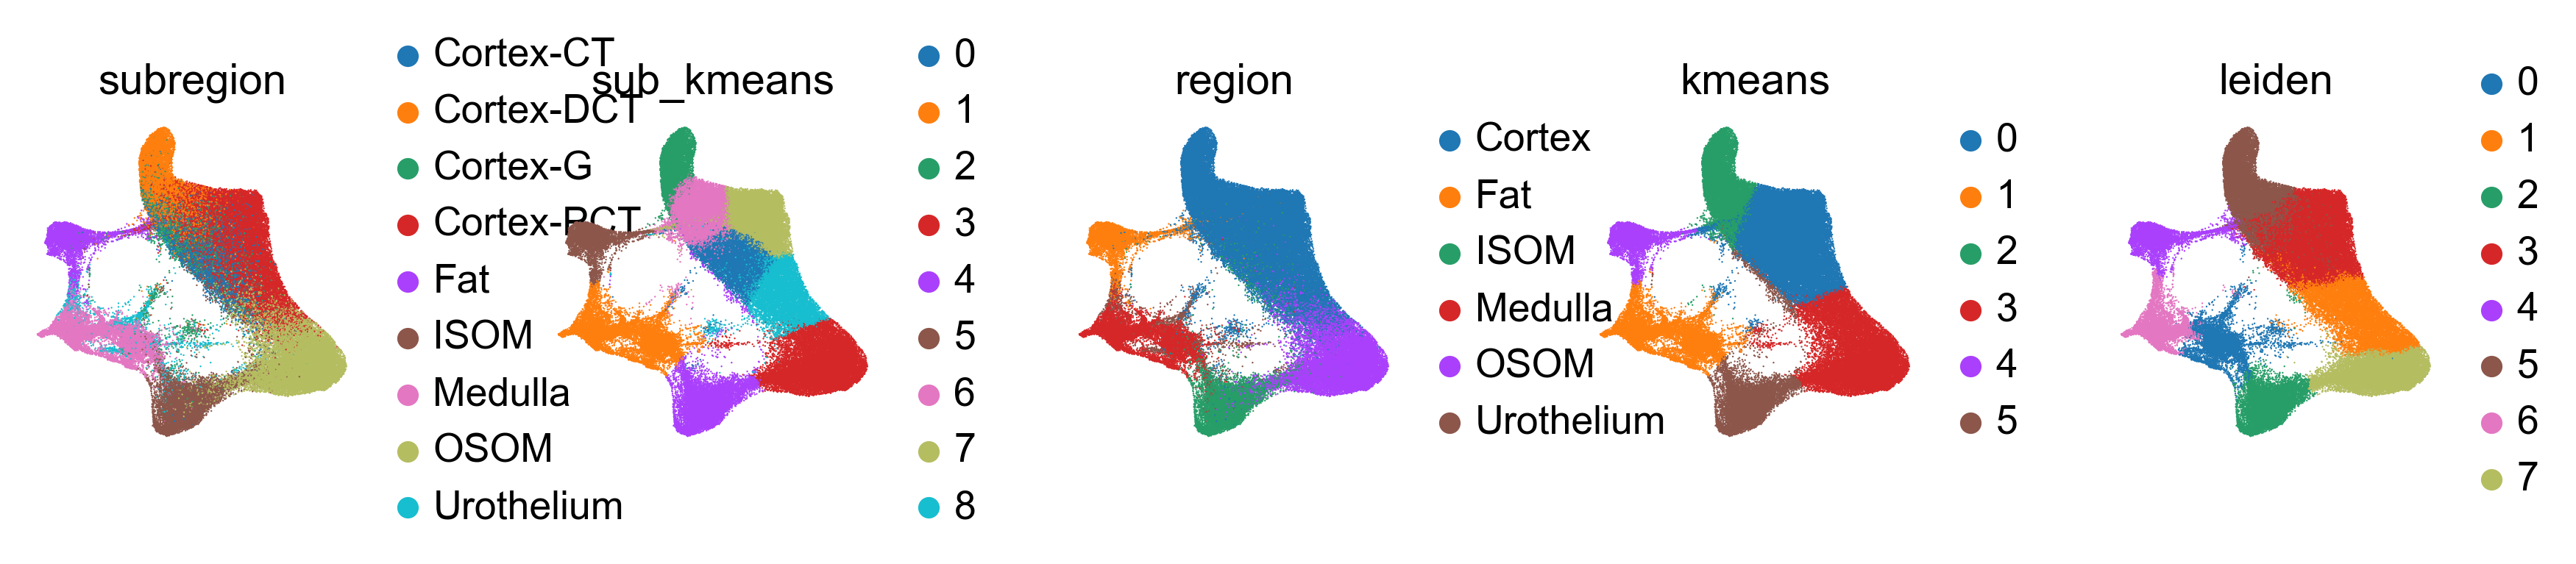

In [15]:
sc.pl.umap(adata_int, color=['subregion', 'sub_kmeans', 'region', 'kmeans', 'leiden'], ncols=6)

In [16]:
batch_names = adata_int.obs.loc[:, 'batch'].unique()

2


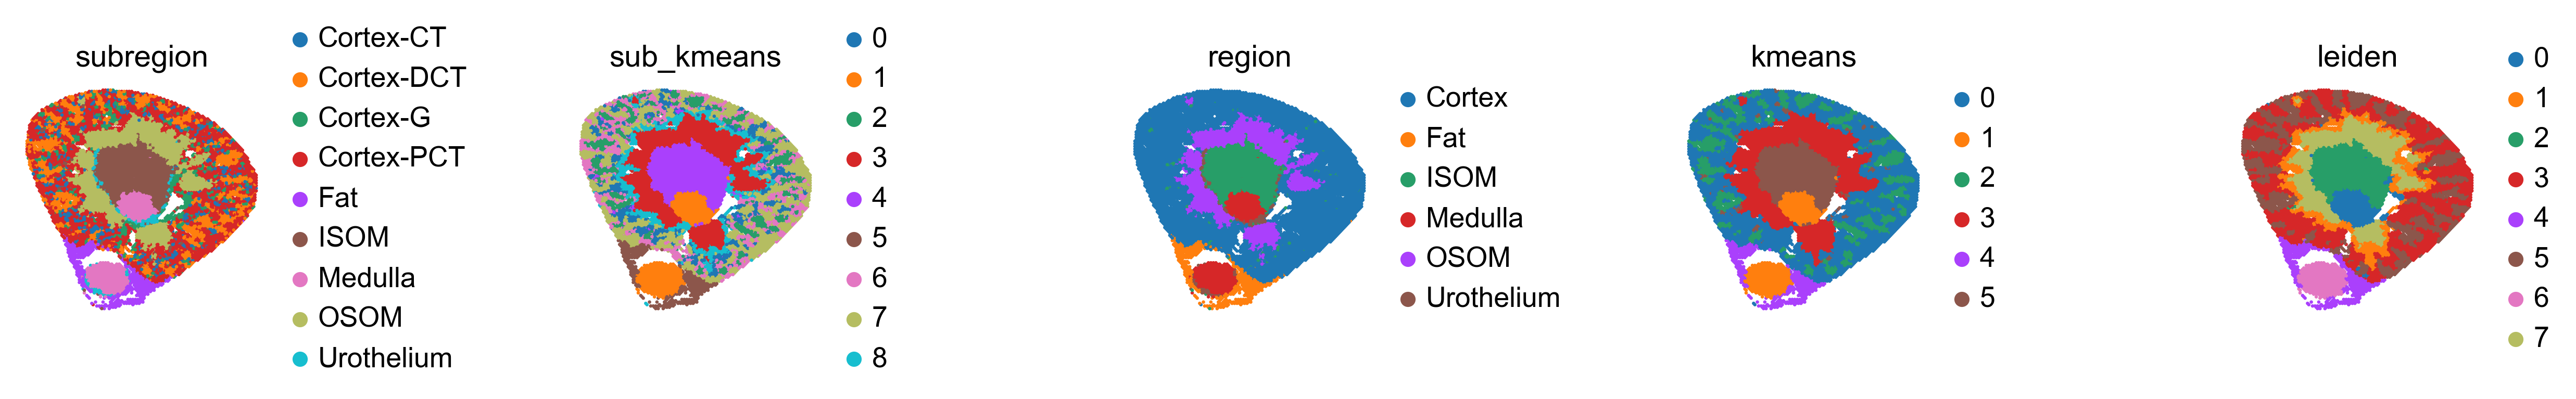

4


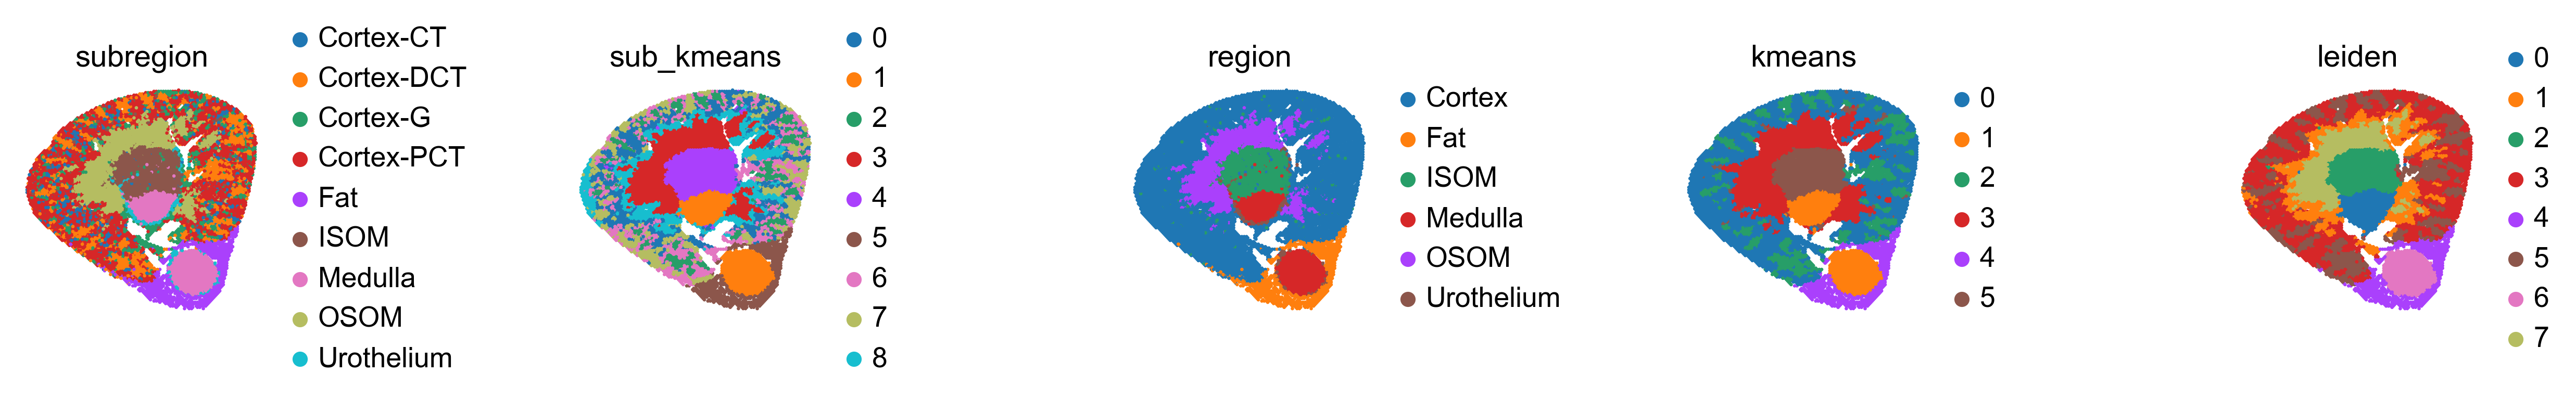

5


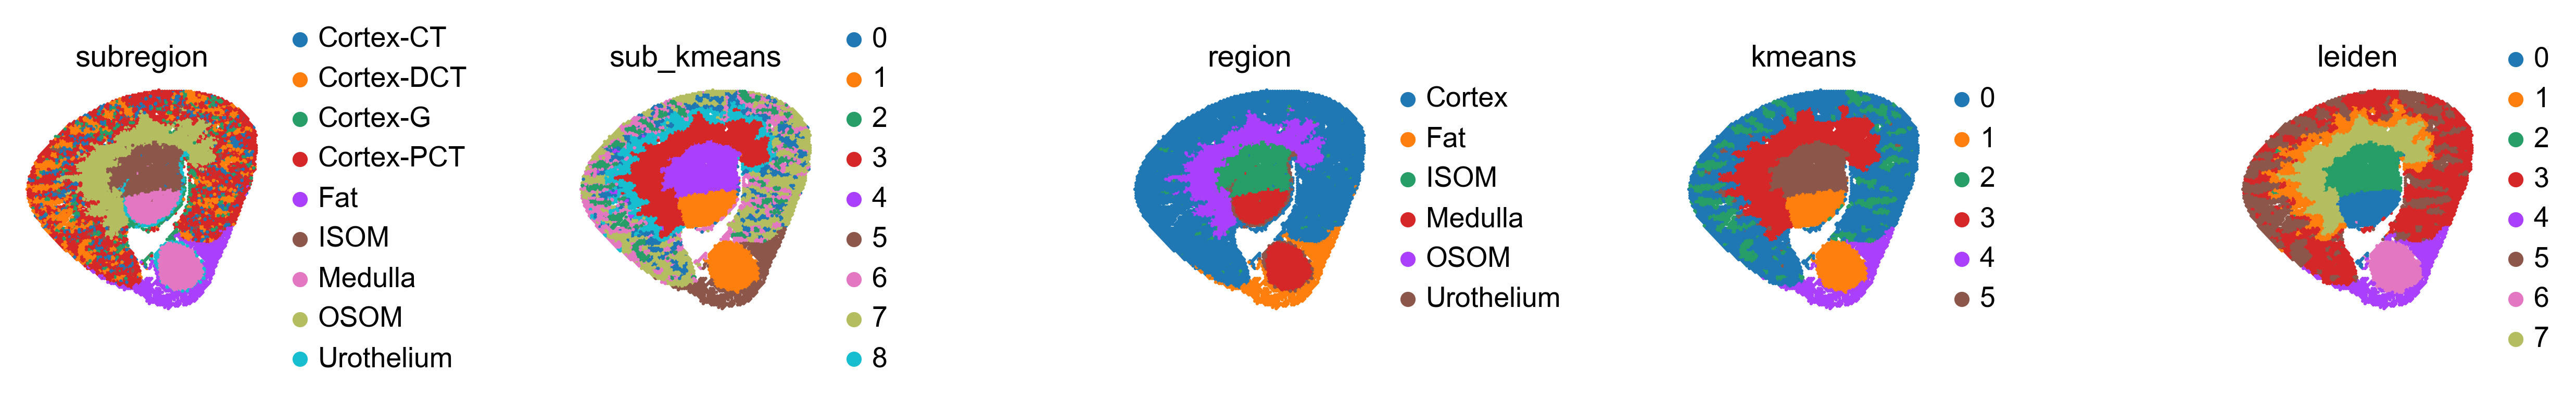

6


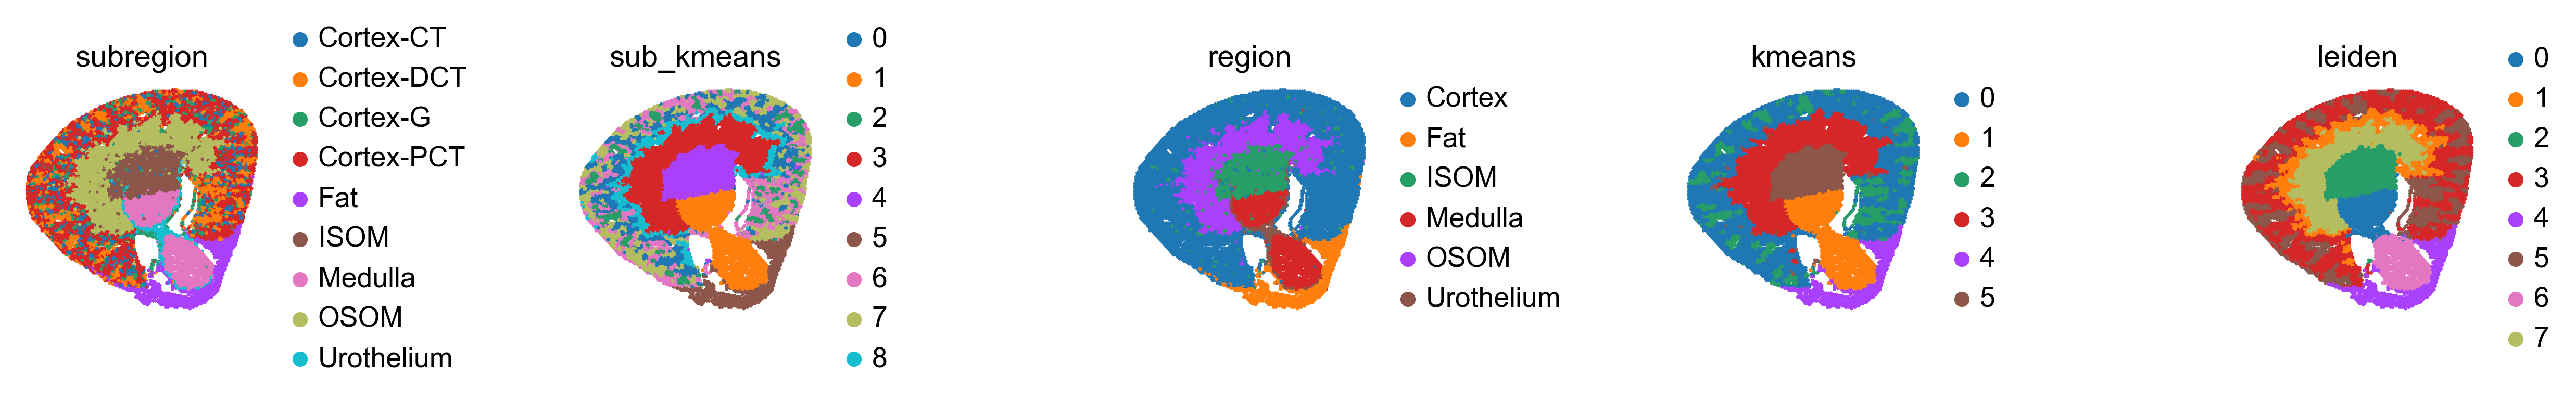

7


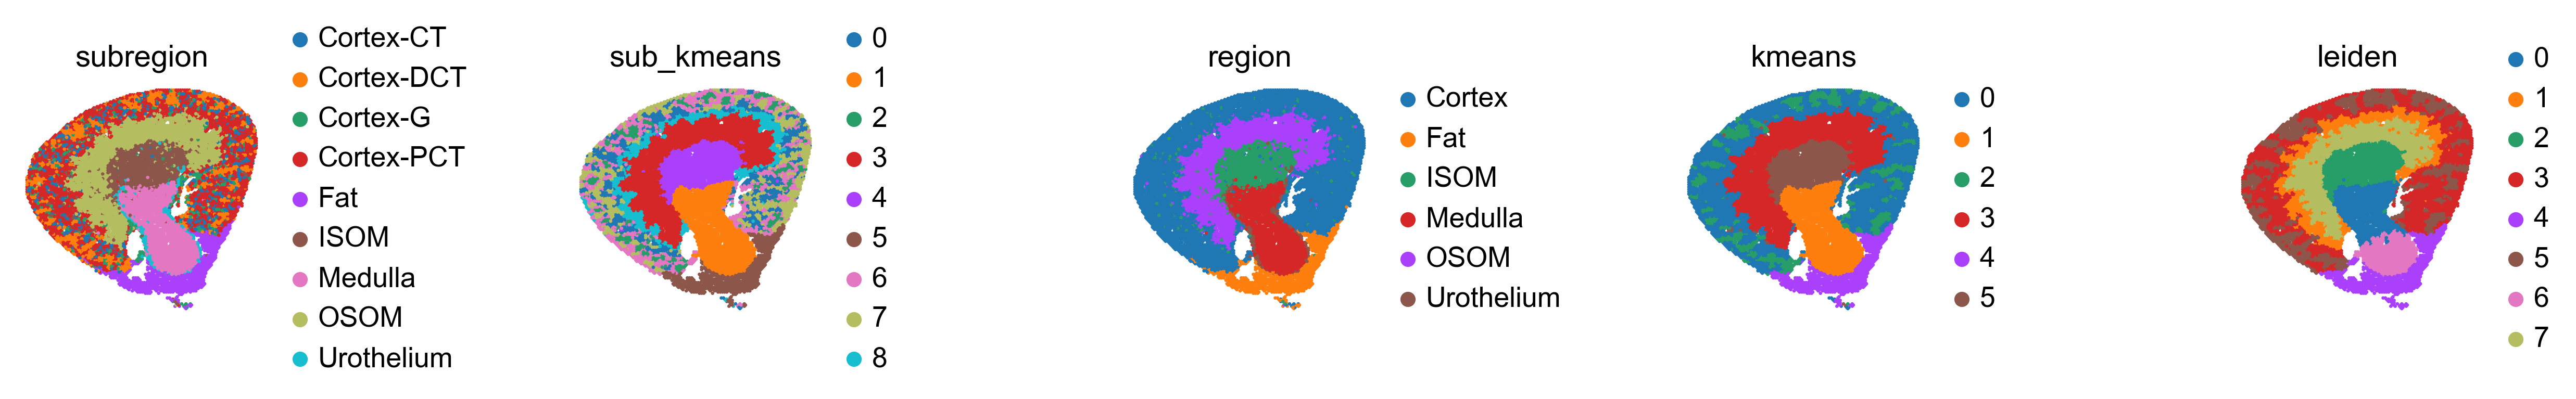

8


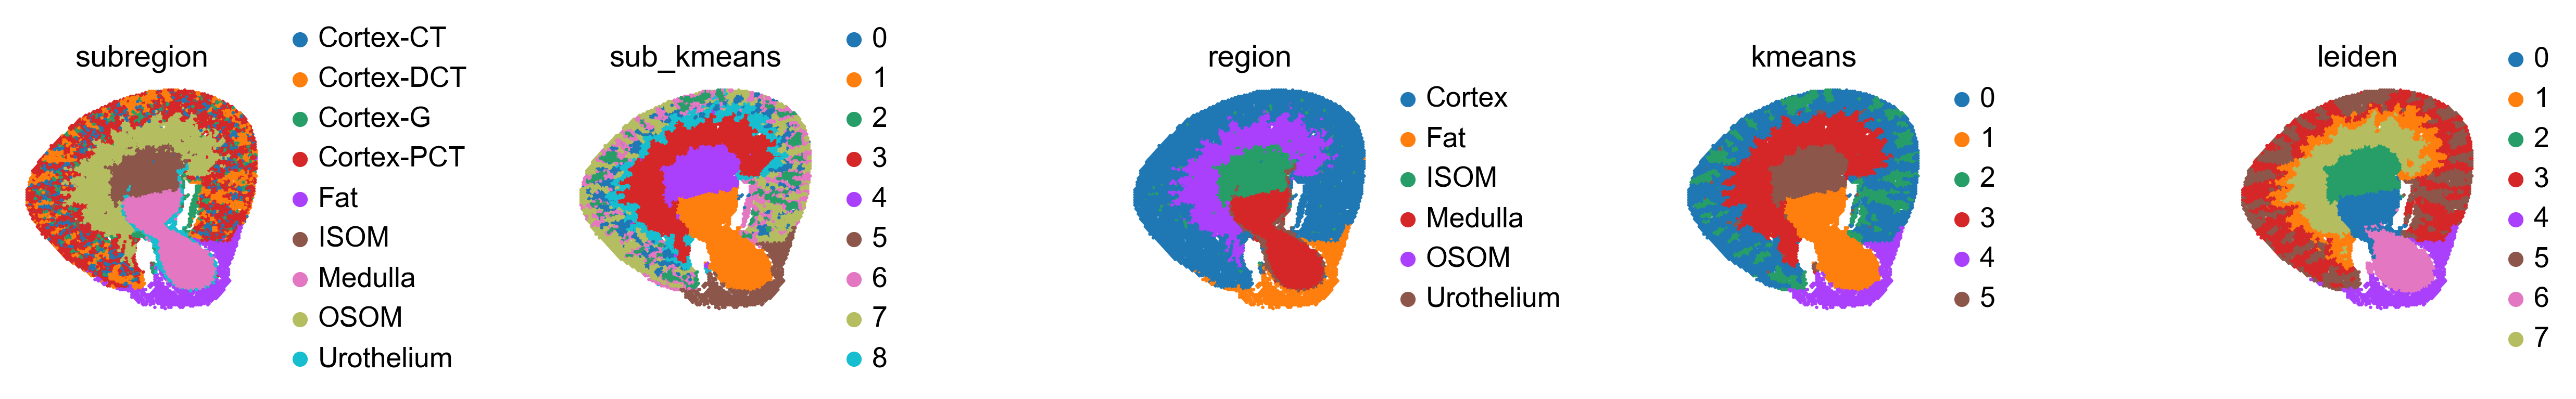

9


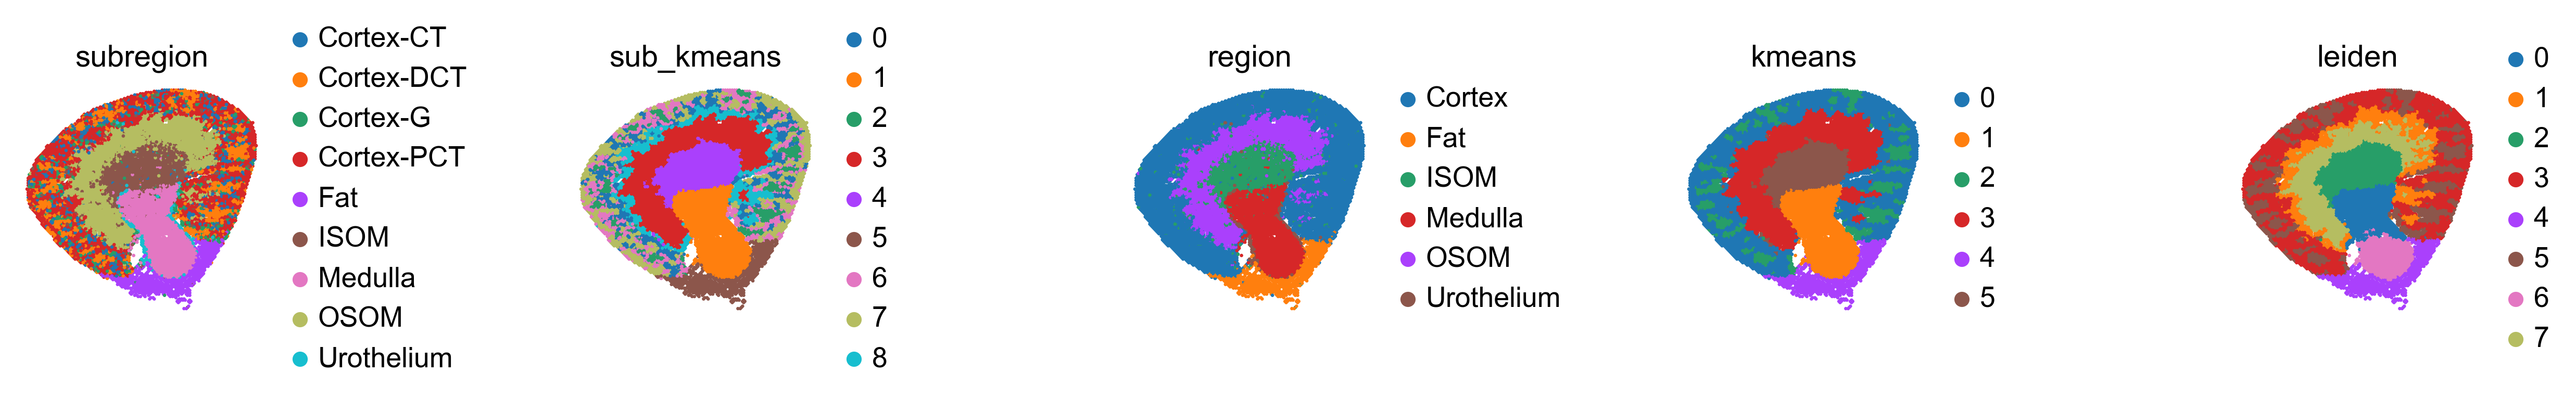

10


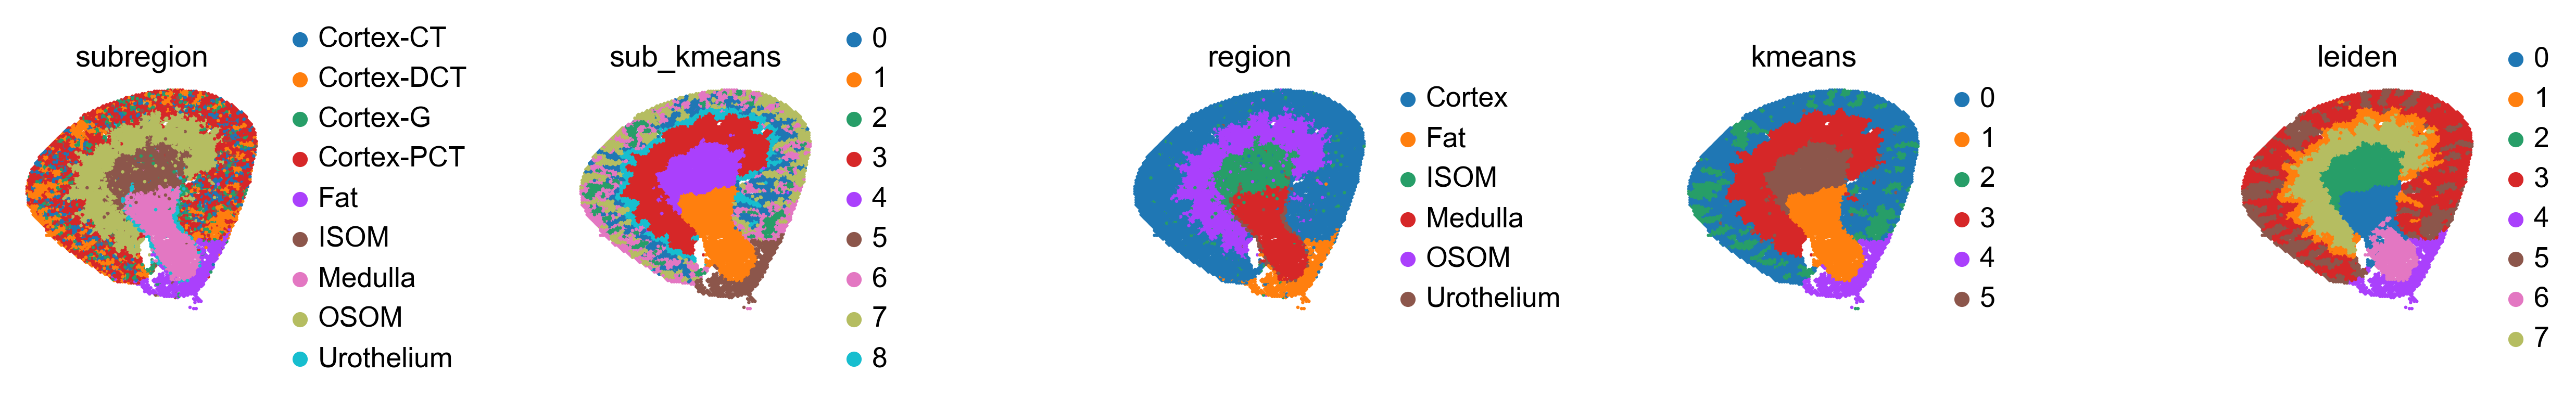

In [17]:
for batch in batch_names:
    temp = adata_int[adata_int.obs.loc[:, 'batch'] == batch, :]
    print(batch)
    sc.pl.embedding(temp, color=['subregion', 'sub_kmeans', 'region', 'kmeans', 'leiden'], ncols=5, basis='spatial', size=10, wspace=1)